# EDA Profundo — Fashion Feature Extraction

Análisis exploratorio exhaustivo sobre los datasets `pants_1.csv` (41.868 pantalones, Abercrombie) y `tops_1.csv` (78.686 prendas superiores, Macy's).

**Objetivo:** ir más allá del EDA descriptivo tradicional y producir **artefactos accionables** para el pipeline de training:
- Class weights por atributo (listos para pegar en `train.py`)
- Mapeo EN→ES alineado con la ontología de `config/pipeline_config.yaml`
- Detección temprana de ruido de labels y variantes de string
- Propuesta de splits estratificados 70/15/15
- Análisis estadístico avanzado: entropía, Chi-cuadrado y V de Cramér entre atributos

**Secciones:**
1. Configuración y carga
2. Integridad y calidad básica
3. Consistencia de strings (nuevo)
4. Cardinalidad y desbalance (entropía)
5. Análisis estadístico avanzado (Chi-sq + Cramér's V)
6. Comparación pants vs tops
7. Validación visual de imágenes (descarga de muestra)
8. Cobertura y patrones de missingness
9. Insights accionables para training
10. Resumen ejecutivo


## 1. Configuración y carga


In [12]:
from google.colab import auth
auth.authenticate_user()
print('Autenticación exitosa.')

Autenticación exitosa.


In [13]:
!pip install gcsfs==2023.10.0


In [14]:
# Imports core
import hashlib
import io
import os
import warnings
from collections import Counter
from difflib import SequenceMatcher
from pathlib import Path
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Imports estadísticos
from scipy import stats
from scipy.stats import chi2_contingency, entropy

# Imports opcionales para imágenes
try:
    from PIL import Image
    import requests
    IMAGES_AVAILABLE = True
except ImportError:
    IMAGES_AVAILABLE = False
    print("⚠️  PIL o requests no disponibles — la sección 7 se saltará")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Parámetros
SAMPLE_SIZE_IMAGES = 200
DOWNLOAD_IMAGES = True  # poner en False para saltar la sección 7
CACHE_DIR = Path("../data/raw/eda_sample")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Seed: {SEED}")
print(f"Muestra de imágenes: {SAMPLE_SIZE_IMAGES}")
print(f"Descarga habilitada: {DOWNLOAD_IMAGES and IMAGES_AVAILABLE}")
print(f"Cache: {CACHE_DIR.resolve()}")


Seed: 42
Muestra de imágenes: 200
Descarga habilitada: True
Cache: /data/raw/eda_sample


In [15]:
# Paths y carga de CSVs
# base_dir = Path("../data/preprocessed") # Comenta o elimina esta línea
base_dir_gcs = "gs://jbj-vision/data/preprocessed" # Nueva ruta al bucket
pants_path = f"{base_dir_gcs}/pants_1.csv"
tops_path = f"{base_dir_gcs}/tops_1.csv"


try:
    df_pants = pd.read_csv(pants_path)
except FileNotFoundError:
    df_pants = None

try:
    df_tops = pd.read_csv(tops_path)
except FileNotFoundError:
    df_tops = None

assert df_pants is not None, f"No se encontró {pants_path}"
assert df_tops is not None, f"No se encontró {tops_path}"

print(f"Pants: {df_pants.shape[0]:,} filas × {df_pants.shape[1]} columnas")
print(f"Tops:  {df_tops.shape[0]:,} filas × {df_tops.shape[1]} columnas")

Pants: 41,868 filas × 8 columnas
Tops:  78,686 filas × 8 columnas


In [16]:
# Overview general
print("=" * 70)
print("DTYPES — pants")
print("=" * 70)
print(df_pants.dtypes)
print()
print("=" * 70)
print("DTYPES — tops")
print("=" * 70)
print(df_tops.dtypes)
print()
print(f"Memoria pants: {df_pants.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Memoria tops:  {df_tops.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


DTYPES — pants
id                 int64
image_url         object
color_family      object
pattern           object
fit_silhouette    object
fabric_content    object
dressing_syle     object
waist_rise        object
dtype: object

DTYPES — tops
id                 int64
image_url         object
color_family      object
pattern           object
fit_silhouette    object
fabric_content    object
dressing_syle     object
neck_style        object
dtype: object

Memoria pants: 19.19 MB
Memoria tops:  36.22 MB


In [17]:
# Atributos por dataset
FEATURES_PANTS = ["color_family", "pattern", "fit_silhouette",
                  "fabric_content", "dressing_syle", "waist_rise"]
FEATURES_TOPS = ["color_family", "pattern", "fit_silhouette",
                 "fabric_content", "dressing_syle", "neck_style"]
FEATURES_SHARED = [f for f in FEATURES_PANTS if f in FEATURES_TOPS]

print(f"Atributos compartidos ({len(FEATURES_SHARED)}): {FEATURES_SHARED}")
print(f"Exclusivos pants: {set(FEATURES_PANTS) - set(FEATURES_TOPS)}")
print(f"Exclusivos tops:  {set(FEATURES_TOPS) - set(FEATURES_PANTS)}")

df_pants.head(3)


Atributos compartidos (5): ['color_family', 'pattern', 'fit_silhouette', 'fabric_content', 'dressing_syle']
Exclusivos pants: {'waist_rise'}
Exclusivos tops:  {'neck_style'}


,id,image_url,color_family,pattern,fit_silhouette,fabric_content,dressing_syle,waist_rise
0,3309,https://img.abercrombie.com/is/image/anf/KIC_1...,Neutrals-Dark,Non-Pattern/Solid,Regular-Fit-Pant,Polyester,Minimalist,Mid-Rise
1,5535,https://img.abercrombie.com/is/image/anf/KIC_1...,Neutrals-Light,Non-Pattern/Solid,Regular-Fit-Pant,Polyester,Minimalist,Mid-Rise
2,14170,https://img.abercrombie.com/is/image/anf/KIC_1...,Neutrals-Dark,Non-Pattern/Solid,Regular-Fit-Pant,Cotton,Minimalist,Mid-Rise


In [18]:
df_tops.head(3)


,id,image_url,color_family,pattern,fit_silhouette,fabric_content,dressing_syle,neck_style
0,6329909,https://slimages.macysassets.com/is/image/MCY/...,Neutrals-Dark,Non-Pattern/Solid,Slim-Fit,Modal,Minimalist,Crew-Neck
1,6369917,https://slimages.macysassets.com/is/image/MCY/...,Neutrals-Dark,Non-Pattern/Solid,Relaxed-Fit,Polyester,Minimalist,Collared-Neck
2,6369936,https://slimages.macysassets.com/is/image/MCY/...,Neutrals-Light,Non-Pattern/Solid,Relaxed-Fit,Linen,Classic,Collared-Neck


## 2. Integridad y calidad básica


In [19]:
def analyze_nulls(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Calcula nulos y porcentaje de completitud por columna."""
    nulls = df.isnull().sum()
    pct = (nulls / len(df) * 100).round(2)
    completeness = (100 - pct).round(2)
    result = pd.DataFrame({
        "nulos": nulls,
        "pct_nulos": pct,
        "completitud_pct": completeness,
    }).sort_values("pct_nulos", ascending=False)
    print(f"\n— Nulos en {name} ({len(df):,} filas) —")
    return result

display(analyze_nulls(df_pants, "Pants"))
display(analyze_nulls(df_tops, "Tops"))



— Nulos en Pants (41,868 filas) —


,nulos,pct_nulos,completitud_pct
id,0,0.0,100.0
image_url,0,0.0,100.0
color_family,0,0.0,100.0
pattern,0,0.0,100.0
fit_silhouette,0,0.0,100.0
fabric_content,0,0.0,100.0
dressing_syle,0,0.0,100.0
waist_rise,0,0.0,100.0



— Nulos en Tops (78,686 filas) —


,nulos,pct_nulos,completitud_pct
id,0,0.0,100.0
image_url,0,0.0,100.0
color_family,0,0.0,100.0
pattern,0,0.0,100.0
fit_silhouette,0,0.0,100.0
fabric_content,0,0.0,100.0
dressing_syle,0,0.0,100.0
neck_style,0,0.0,100.0


In [20]:
# Duplicados
def analyze_duplicates(df: pd.DataFrame, name: str) -> None:
    dup_id = df.duplicated(subset=["id"]).sum()
    dup_url = df.duplicated(subset=["image_url"]).sum()
    dup_all = df.duplicated().sum()
    print(f"— {name} —")
    print(f"  Duplicados por id:        {dup_id:,} ({dup_id/len(df)*100:.2f}%)")
    print(f"  Duplicados por image_url: {dup_url:,} ({dup_url/len(df)*100:.2f}%)")
    print(f"  Filas idénticas:          {dup_all:,} ({dup_all/len(df)*100:.2f}%)")

analyze_duplicates(df_pants, "Pants")
print()
analyze_duplicates(df_tops, "Tops")


— Pants —
  Duplicados por id:        0 (0.00%)
  Duplicados por image_url: 22,623 (54.03%)
  Filas idénticas:          0 (0.00%)

— Tops —
  Duplicados por id:        0 (0.00%)
  Duplicados por image_url: 29,009 (36.87%)
  Filas idénticas:          0 (0.00%)


In [21]:
# Validación de URLs
def analyze_urls(df: pd.DataFrame, name: str) -> None:
    urls = df["image_url"].dropna()
    domains = urls.apply(lambda x: urlparse(str(x)).netloc)
    domain_counts = domains.value_counts()

    # URLs que no parecen válidas
    invalid = urls[~urls.str.startswith(("http://", "https://"))]

    print(f"— {name} —")
    print(f"  URLs totales:      {len(urls):,}")
    print(f"  URLs no-http:      {len(invalid):,}")
    print(f"  Dominios únicos:   {domain_counts.nunique()}")
    print(f"  Top 3 dominios:")
    for d, c in domain_counts.head(3).items():
        print(f"    - {d}: {c:,} ({c/len(urls)*100:.1f}%)")

analyze_urls(df_pants, "Pants")
print()
analyze_urls(df_tops, "Tops")


— Pants —
  URLs totales:      41,868
  URLs no-http:      0
  Dominios únicos:   14
  Top 3 dominios:
    - img.fruugo.com: 33,909 (81.0%)
    - asset1.ruecdn.com: 4,721 (11.3%)
    - slimages.macysassets.com: 1,181 (2.8%)

— Tops —
  URLs totales:      78,686
  URLs no-http:      0
  Dominios únicos:   7
  Top 3 dominios:
    - img.fruugo.com: 49,988 (63.5%)
    - asset1.ruecdn.com: 16,175 (20.6%)
    - slimages.macysassets.com: 9,441 (12.0%)


## 3. Consistencia de strings

Los labels vienen como strings crudos del scraper. Buscamos variantes accidentales (case, espacios, guiones) y posibles typos que deberían merge-arse antes de entrenar.


In [22]:
def detect_string_variants(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Detecta variantes de case/espaciado dentro de cada columna categórica."""
    variants_found = []
    for col in columns:
        if col not in df.columns:
            continue
        values = df[col].dropna().astype(str)
        # Normalizar: lower + strip + reemplazar variantes de separador
        normalized_map = {}
        for v in values.unique():
            key = v.lower().strip().replace("-", " ").replace("_", " ")
            key = " ".join(key.split())  # colapsar espacios múltiples
            normalized_map.setdefault(key, set()).add(v)
        # Solo reportar claves con >1 variante
        for key, group in normalized_map.items():
            if len(group) > 1:
                variants_found.append({
                    "columna": col,
                    "forma_canonica": key,
                    "n_variantes": len(group),
                    "variantes": sorted(group),
                })
    return pd.DataFrame(variants_found)

variants_pants = detect_string_variants(df_pants, FEATURES_PANTS)
variants_tops = detect_string_variants(df_tops, FEATURES_TOPS)

print(f"Pants: {len(variants_pants)} grupos con variantes")
print(f"Tops:  {len(variants_tops)} grupos con variantes")
if not variants_pants.empty:
    display(variants_pants.head(10))
if not variants_tops.empty:
    display(variants_tops.head(10))


Pants: 0 grupos con variantes
Tops:  0 grupos con variantes


In [23]:
def find_fuzzy_duplicates(values: list[str], threshold: float = 0.85) -> list[tuple]:
    """Encuentra pares de strings con similitud > threshold (posibles typos)."""
    pairs = []
    vals = sorted(set(values))
    for i, a in enumerate(vals):
        for b in vals[i + 1:]:
            ratio = SequenceMatcher(None, a.lower(), b.lower()).ratio()
            if ratio >= threshold:
                pairs.append((a, b, round(ratio, 3)))
    return pairs

for name, df, feats in [("Pants", df_pants, FEATURES_PANTS),
                        ("Tops", df_tops, FEATURES_TOPS)]:
    print(f"\n— Candidatos a merge por similitud (>= 0.85) en {name} —")
    for col in feats:
        if col not in df.columns:
            continue
        uniq = df[col].dropna().astype(str).unique().tolist()
        if len(uniq) > 200:  # evitar explosión combinatoria
            continue
        pairs = find_fuzzy_duplicates(uniq, threshold=0.85)
        if pairs:
            print(f"  [{col}] {len(pairs)} pares sospechosos:")
            for a, b, r in pairs[:5]:
                print(f"    '{a}' ≈ '{b}'  (sim={r})")



— Candidatos a merge por similitud (>= 0.85) en Pants —
  [color_family] 1 pares sospechosos:
    'Bright-Colors' ≈ 'Light-Colors'  (sim=0.88)
  [fabric_content] 1 pares sospechosos:
    'Pima-Cotton' ≈ 'Supima-Cotton'  (sim=0.917)

— Candidatos a merge por similitud (>= 0.85) en Tops —
  [color_family] 1 pares sospechosos:
    'Bright-Colors' ≈ 'Light-Colors'  (sim=0.88)
  [fabric_content] 1 pares sospechosos:
    'Pima-Cotton' ≈ 'Supima-Cotton'  (sim=0.917)
  [neck_style] 1 pares sospechosos:
    'Band-Collar' ≈ 'Stand-Collar'  (sim=0.87)


In [24]:
# Análisis de tokens: vocabulario base por atributo
def tokenize_values(df: pd.DataFrame, col: str) -> Counter:
    if col not in df.columns:
        return Counter()
    tokens = []
    for v in df[col].dropna().astype(str):
        tokens.extend(v.replace("-", " ").replace("_", " ").lower().split())
    return Counter(tokens)

print("— Vocabulario base por atributo (Pants) —")
for col in FEATURES_PANTS:
    toks = tokenize_values(df_pants, col)
    print(f"  [{col}] top-8 tokens: {toks.most_common(8)}")

print("\n— Vocabulario base por atributo (Tops) —")
for col in FEATURES_TOPS:
    toks = tokenize_values(df_tops, col)
    print(f"  [{col}] top-8 tokens: {toks.most_common(8)}")


— Vocabulario base por atributo (Pants) —
  [color_family] top-8 tokens: [('neutrals', 33071), ('dark', 26391), ('light', 10941), ('colors', 7273), ('bright', 3012), ('jewel', 1044), ('tones', 1044), ('pastels', 245)]
  [pattern] top-8 tokens: [('non', 37430), ('pattern/solid', 37430), ('marled', 2134), ('plaid', 1397), ('stripes', 541), ('vertical', 440), ('no', 194), ('print/no', 194)]
  [fit_silhouette] top-8 tokens: [('fit', 41405), ('pant', 41282), ('regular', 29903), ('slim', 6853), ('snug', 3038), ('loose', 1498), ('skinny', 543), ('leg', 462)]
  [fabric_content] top-8 tokens: [('polyester', 11247), ('cotton', 10436), ('knit', 7263), ('spandex/elastane', 4268), ('linen', 2639), ('denim', 2447), ('wool', 1693), ('fleece', 1343)]
  [dressing_syle] top-8 tokens: [('minimalist', 21519), ('chic', 9049), ('boho', 8395), ('edgy/urban', 5280), ('graphics', 2624), ('classic', 2155), ('athleisure', 628), ('holiday', 610)]
  [waist_rise] top-8 tokens: [('mid', 38288), ('rise', 38288), ('wa

## 4. Cardinalidad y desbalance

Medimos por atributo: cardinalidad, entropía de Shannon (bits), ratio mayoritaria/minoritaria y % de clases long-tail (<1% representación).


In [25]:
def shannon_entropy(series: pd.Series, base: float = 2) -> float:
    """Entropía de Shannon en bits."""
    counts = series.dropna().value_counts()
    probs = counts / counts.sum()
    return float(entropy(probs, base=base))


def cardinality_report(df: pd.DataFrame, features: list[str], name: str) -> pd.DataFrame:
    rows = []
    for col in features:
        if col not in df.columns:
            continue
        s = df[col].dropna()
        counts = s.value_counts()
        n_unique = counts.size
        ent = shannon_entropy(s)
        ent_max = np.log2(n_unique) if n_unique > 1 else 1.0
        ent_norm = ent / ent_max if ent_max > 0 else 0
        long_tail = (counts / counts.sum() < 0.01).sum()
        rows.append({
            "atributo": col,
            "n_clases": n_unique,
            "entropia_bits": round(ent, 3),
            "entropia_normalizada": round(ent_norm, 3),
            "top1_pct": round(counts.iloc[0] / counts.sum() * 100, 2),
            "last_pct": round(counts.iloc[-1] / counts.sum() * 100, 4),
            "ratio_mayor_menor": f"{counts.iloc[0] / counts.iloc[-1]:.0f}x",
            "clases_long_tail_<1pct": long_tail,
        })
    out = pd.DataFrame(rows)
    print(f"\n— Cardinalidad y desbalance — {name} —")
    return out

display(cardinality_report(df_pants, FEATURES_PANTS, "Pants"))
display(cardinality_report(df_tops, FEATURES_TOPS, "Tops"))



— Cardinalidad y desbalance — Pants —


,atributo,n_clases,entropia_bits,entropia_normalizada,top1_pct,last_pct,ratio_mayor_menor,clases_long_tail_<1pct
0,color_family,8,1.870,0.623,56.88,0.5613,101x,2
1,pattern,22,0.701,0.157,89.40,0.0024,37430x,18
2,fit_silhouette,11,1.358,0.393,71.42,0.0024,29902x,5
3,fabric_content,81,3.815,0.602,25.68,0.0024,10750x,65
4,dressing_syle,11,2.100,0.607,51.40,0.0072,7173x,3
5,waist_rise,3,0.439,0.277,91.45,0.2723,336x,1



— Cardinalidad y desbalance — Tops —


,atributo,n_clases,entropia_bits,entropia_normalizada,top1_pct,last_pct,ratio_mayor_menor,clases_long_tail_<1pct
0,color_family,8,2.245,0.748,41.98,0.7956,53x,1
1,pattern,24,1.479,0.323,73.27,0.0013,57651x,18
2,fit_silhouette,9,1.478,0.466,61.03,0.0038,16006x,5
3,fabric_content,100,3.606,0.543,26.53,0.0013,20875x,89
4,dressing_syle,12,1.872,0.522,63.49,0.0013,49961x,5
5,neck_style,19,2.460,0.579,36.29,0.0013,28559x,9


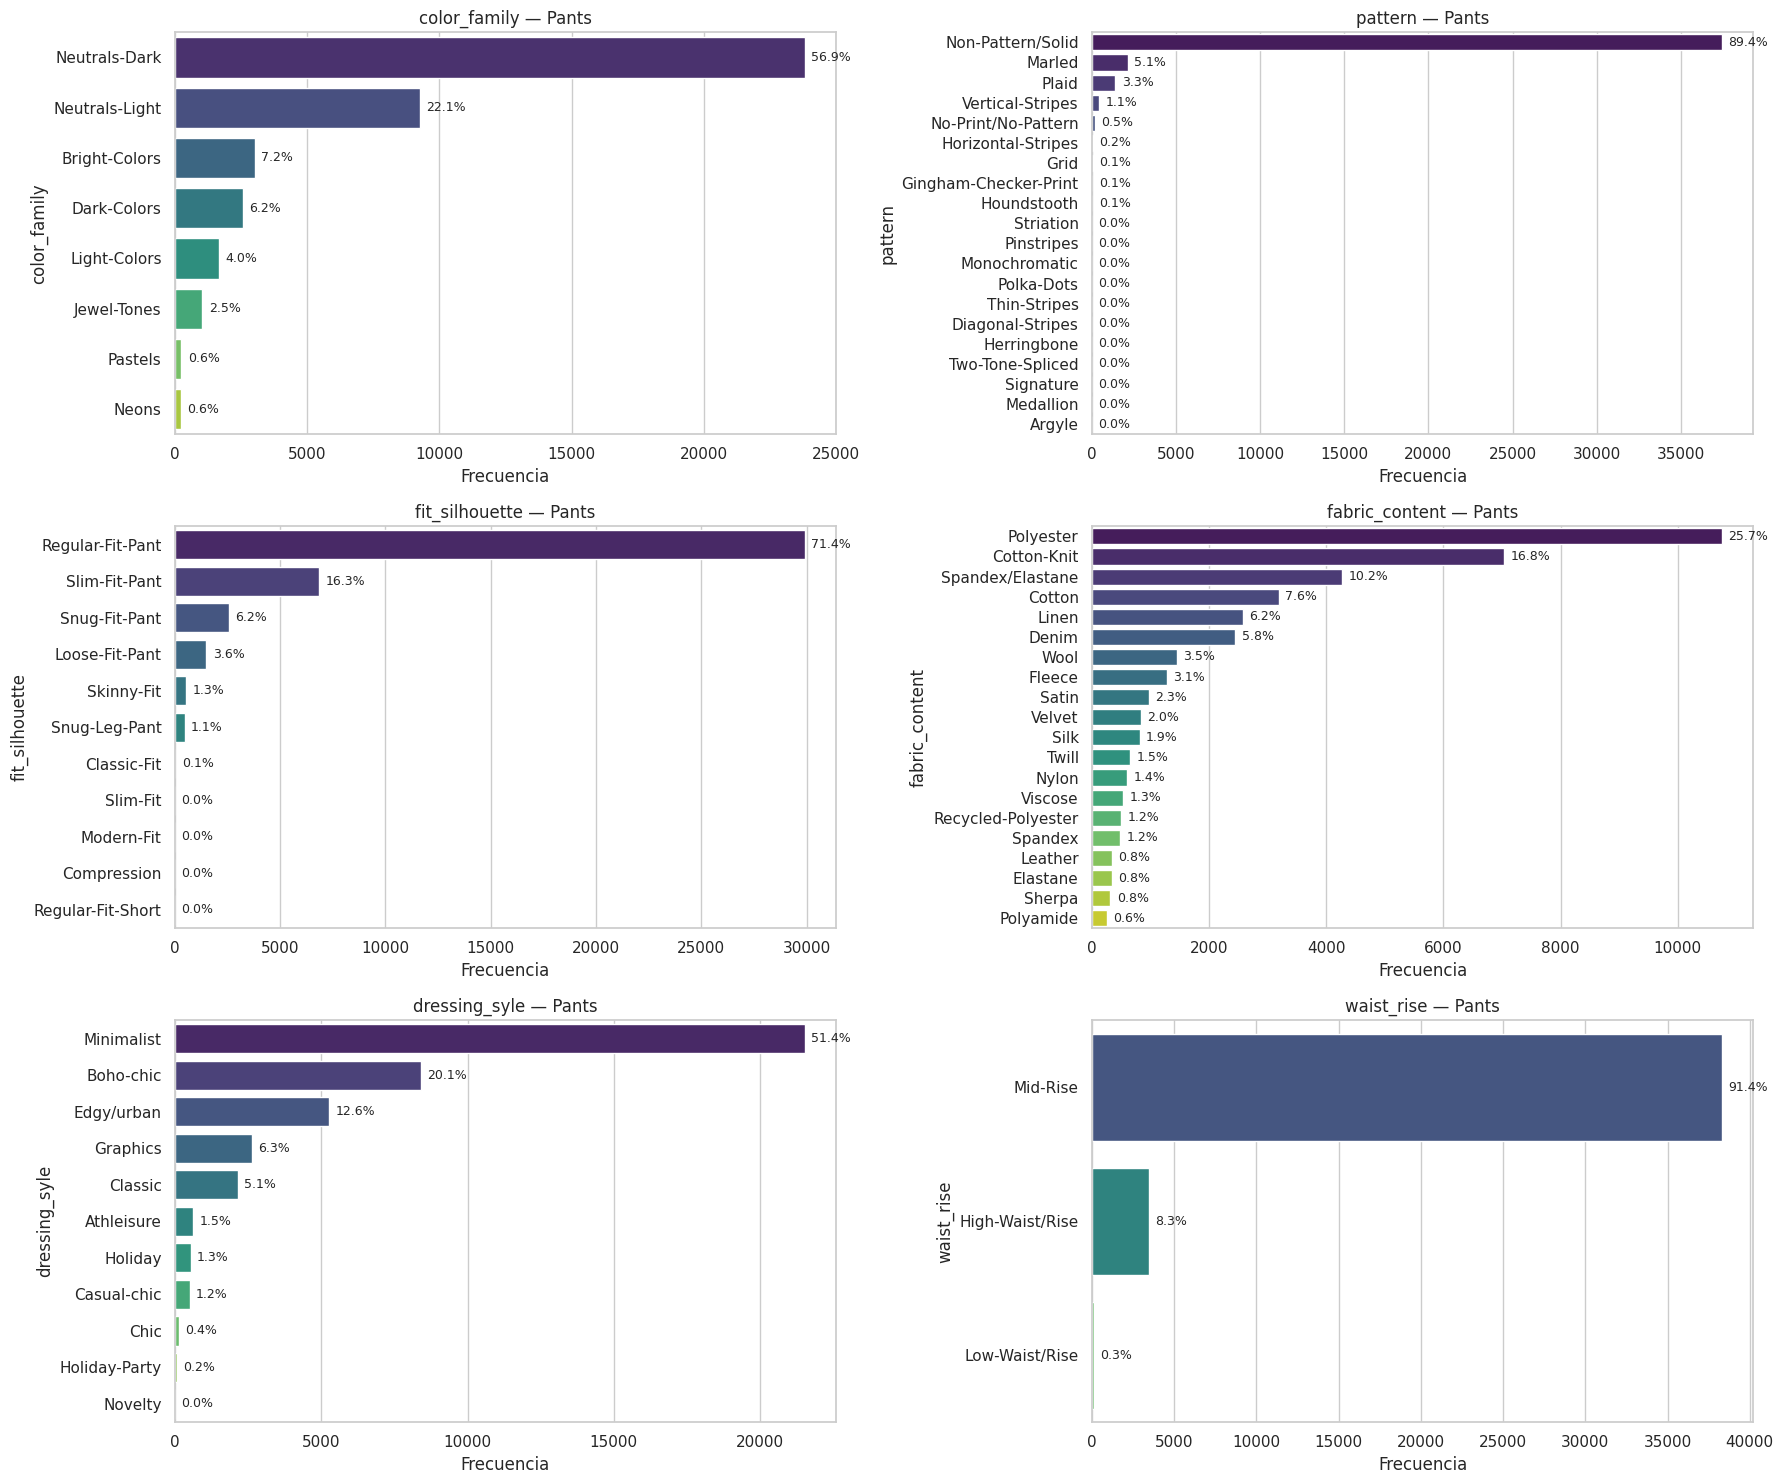

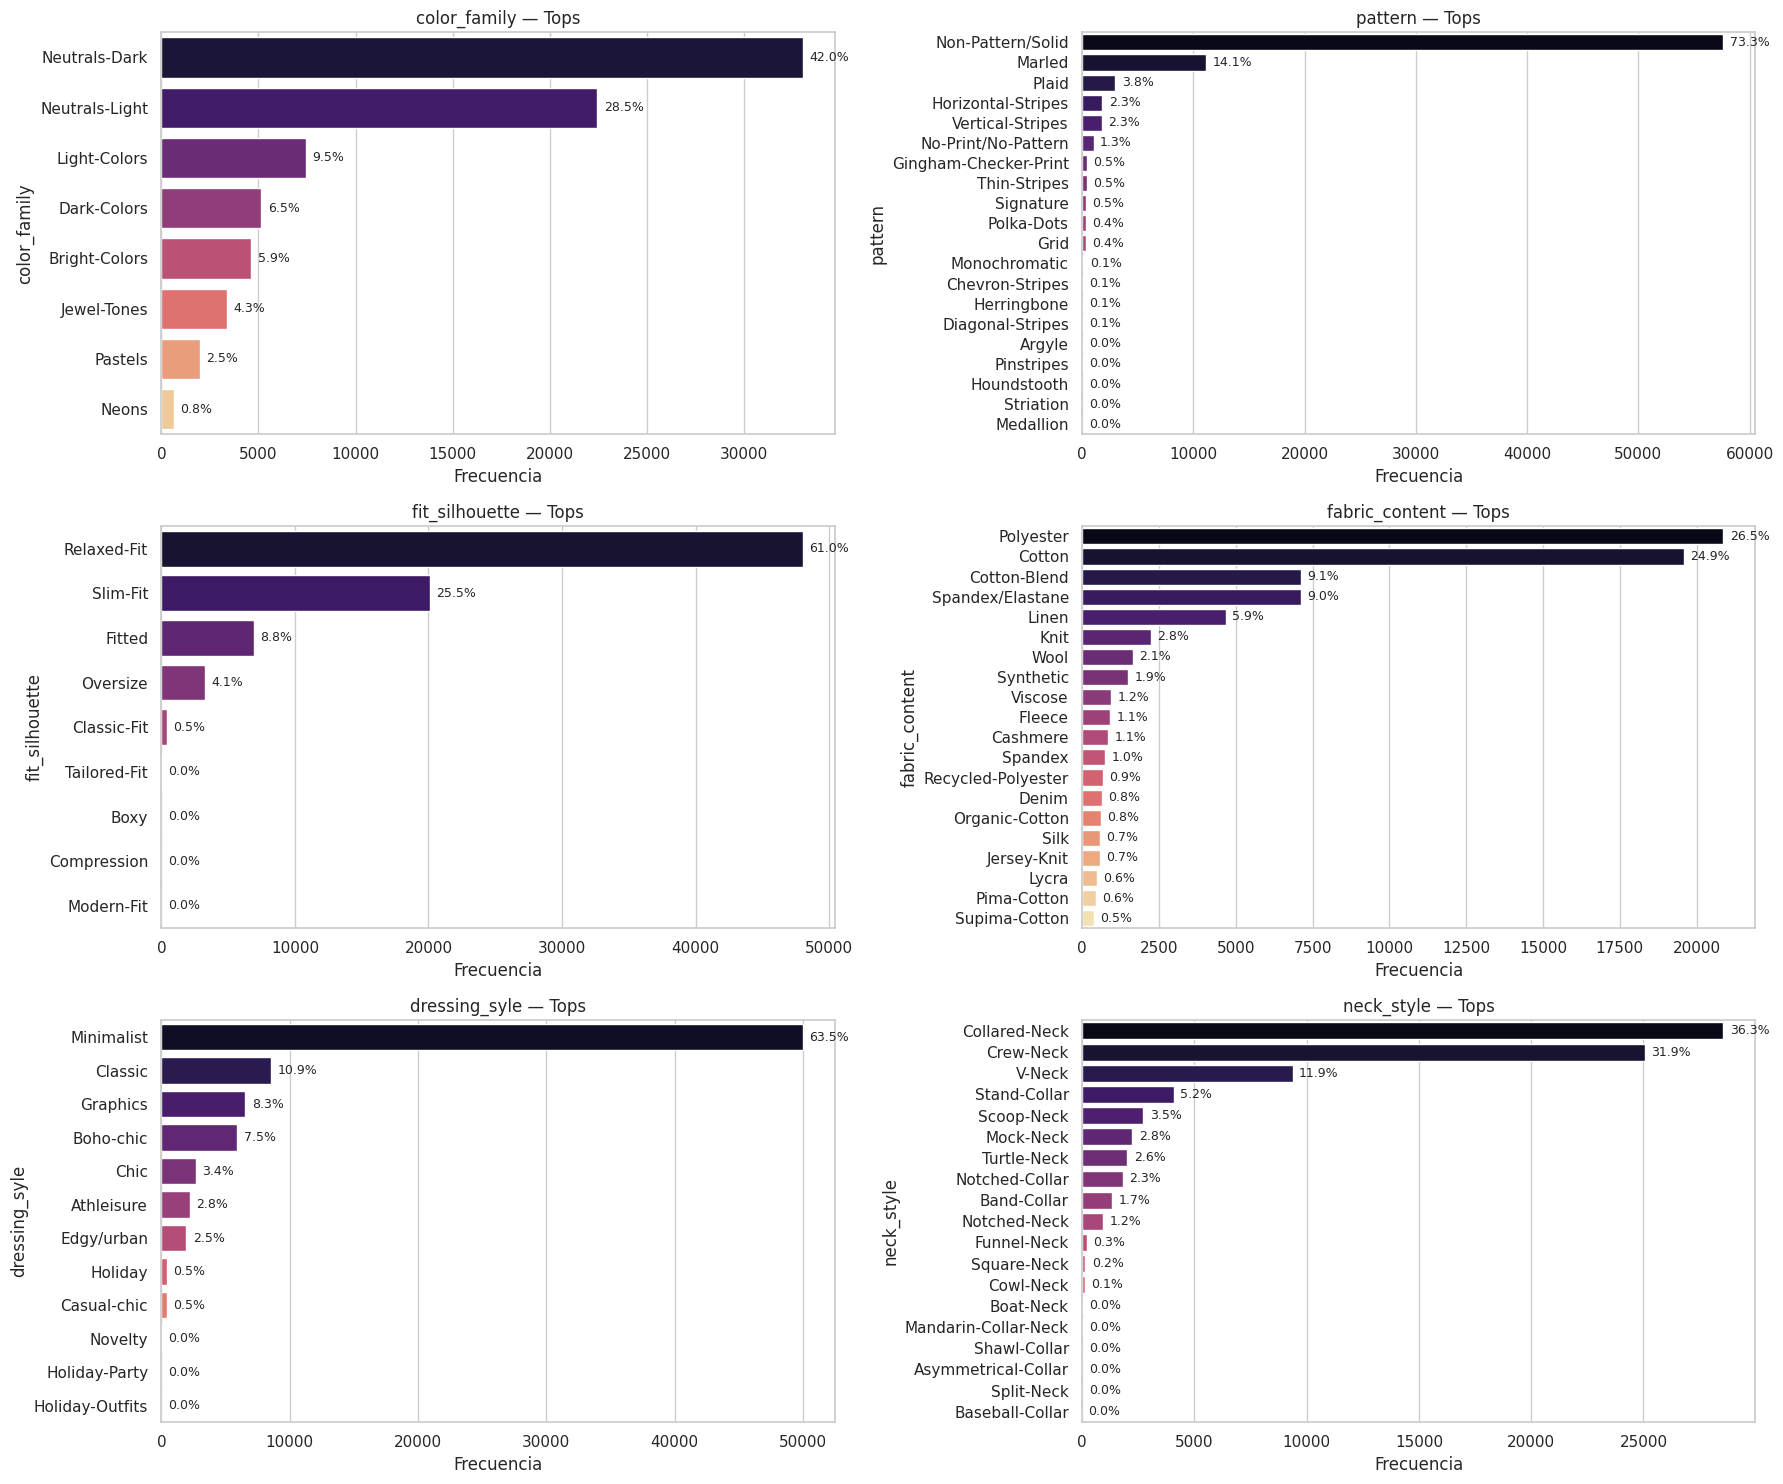

In [26]:
# Distribuciones con % anotado
def plot_distributions(df: pd.DataFrame, features: list[str], name: str, palette: str) -> None:
    existing = [f for f in features if f in df.columns]
    n = len(existing)
    rows = (n + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(18, rows * 5))
    axes = axes.flatten() if n > 1 else [axes]
    for i, feat in enumerate(existing):
        ax = axes[i]
        vc = df[feat].value_counts().head(20)
        sns.barplot(x=vc.values, y=vc.index, ax=ax, palette=palette)
        total = df[feat].notna().sum()
        for p in ax.patches:
            pct = 100 * p.get_width() / total
            ax.annotate(f"{pct:.1f}%",
                        (p.get_x() + p.get_width() + max(vc.values) * 0.01,
                         p.get_y() + p.get_height() / 2),
                        va="center", fontsize=9)
        ax.set_title(f"{feat} — {name}", fontsize=12)
        ax.set_xlabel("Frecuencia")
    for j in range(len(existing), len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

plot_distributions(df_pants, FEATURES_PANTS, "Pants", "viridis")
plot_distributions(df_tops, FEATURES_TOPS, "Tops", "magma")


## 5. Análisis estadístico avanzado

Testeamos **independencia entre atributos** con Chi-cuadrado y cuantificamos la asociación con **V de Cramér**. Atributos altamente asociados sugieren redundancia entre las heads del ViT (y riesgo de leakage si se usan como features vs targets).


In [27]:
def cramers_v(x: pd.Series, y: pd.Series) -> tuple[float, float]:
    """Calcula V de Cramér con corrección de bias. Retorna (V, p-value)."""
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]
    if len(x) == 0:
        return np.nan, np.nan
    confusion = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(confusion)
    n = confusion.to_numpy().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    # Corrección de bias (Bergsma & Wicher 2013)
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    v = np.sqrt(phi2_corr / denom) if denom > 0 else 0.0
    return float(v), float(p)


def cramers_v_matrix(df: pd.DataFrame, features: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    feats = [f for f in features if f in df.columns]
    v_mat = pd.DataFrame(np.zeros((len(feats), len(feats))), index=feats, columns=feats)
    p_mat = pd.DataFrame(np.ones((len(feats), len(feats))), index=feats, columns=feats)
    for i, a in enumerate(feats):
        for b in feats[i:]:
            v, p = cramers_v(df[a], df[b])
            v_mat.loc[a, b] = v_mat.loc[b, a] = v
            p_mat.loc[a, b] = p_mat.loc[b, a] = p
    return v_mat, p_mat

v_pants, p_pants = cramers_v_matrix(df_pants, FEATURES_PANTS)
v_tops, p_tops = cramers_v_matrix(df_tops, FEATURES_TOPS)


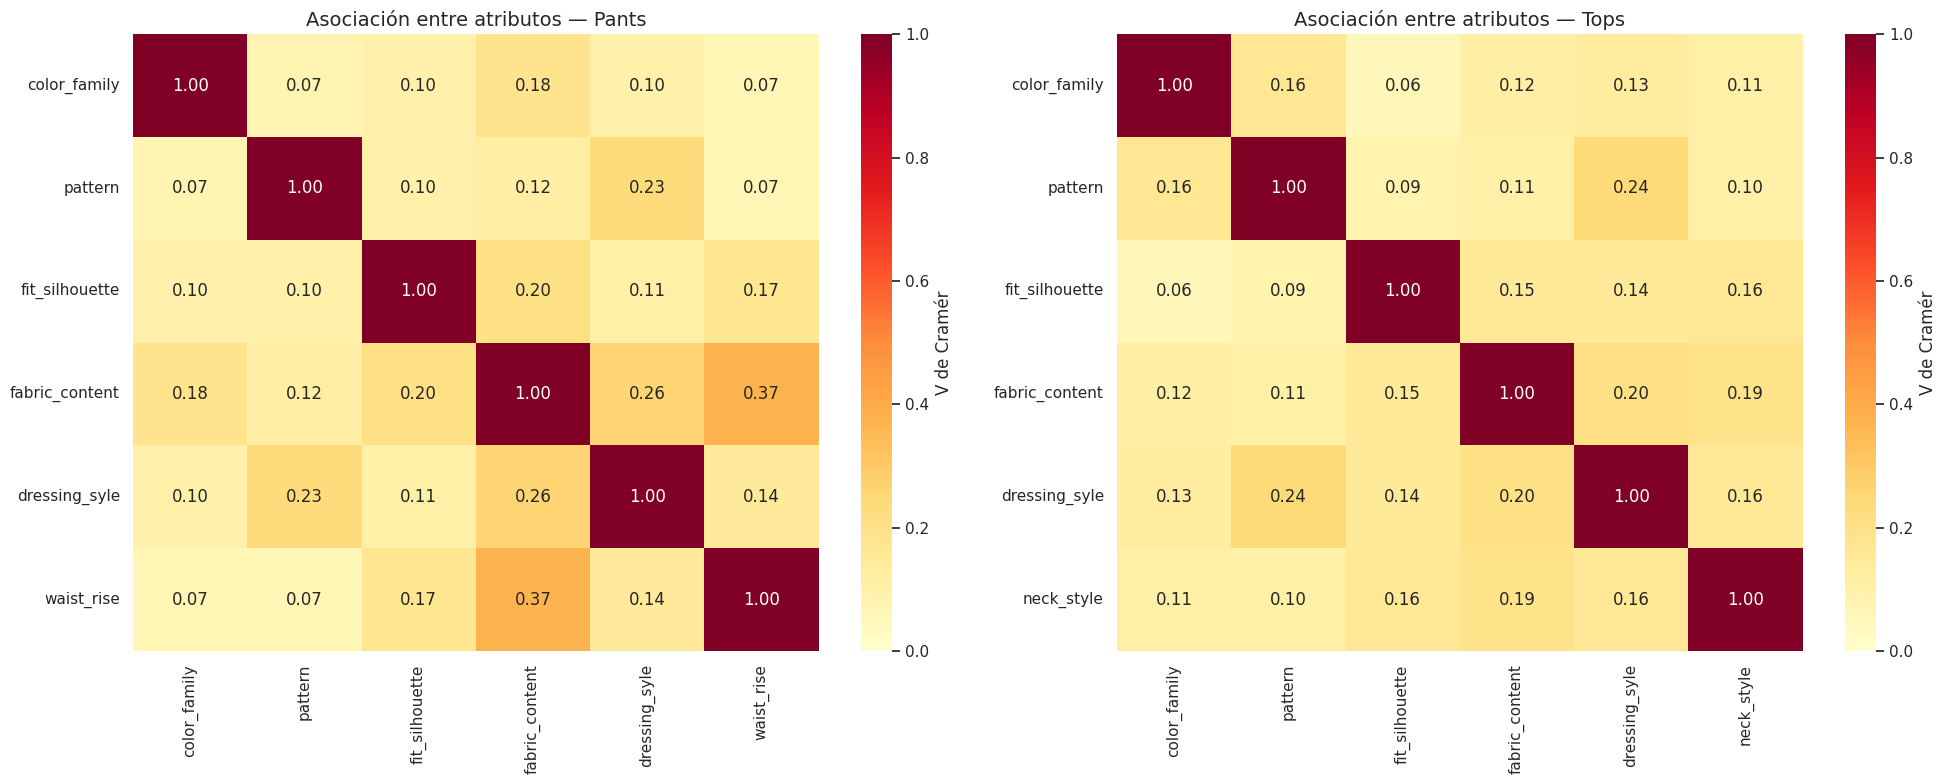


Interpretación V de Cramér:
  0.0-0.1: sin asociación | 0.1-0.3: débil | 0.3-0.5: moderada | >0.5: fuerte


In [28]:
# Visualización de V de Cramér
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(v_pants, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, ax=axes[0], cbar_kws={"label": "V de Cramér"})
axes[0].set_title("Asociación entre atributos — Pants", fontsize=14)

sns.heatmap(v_tops, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, ax=axes[1], cbar_kws={"label": "V de Cramér"})
axes[1].set_title("Asociación entre atributos — Tops", fontsize=14)

plt.tight_layout()
plt.show()

print("\nInterpretación V de Cramér:")
print("  0.0-0.1: sin asociación | 0.1-0.3: débil | 0.3-0.5: moderada | >0.5: fuerte")


In [29]:
# Pares con asociación más fuerte (candidatos a redundancia)
def top_associations(v_mat: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    pairs = []
    feats = v_mat.columns.tolist()
    for i, a in enumerate(feats):
        for b in feats[i + 1:]:
            pairs.append({"atributo_a": a, "atributo_b": b,
                          "V_cramer": round(v_mat.loc[a, b], 3)})
    return pd.DataFrame(pairs).sort_values("V_cramer", ascending=False).head(top_n)

print("— Top 5 pares más asociados en Pants —")
display(top_associations(v_pants))
print("— Top 5 pares más asociados en Tops —")
display(top_associations(v_tops))


— Top 5 pares más asociados en Pants —


,atributo_a,atributo_b,V_cramer
13,fabric_content,waist_rise,0.370
12,fabric_content,dressing_syle,0.264
7,pattern,dressing_syle,0.231
9,fit_silhouette,fabric_content,0.204
2,color_family,fabric_content,0.183


— Top 5 pares más asociados en Tops —


,atributo_a,atributo_b,V_cramer
7,pattern,dressing_syle,0.244
12,fabric_content,dressing_syle,0.204
13,fabric_content,neck_style,0.191
0,color_family,pattern,0.164
11,fit_silhouette,neck_style,0.157


## 6. Comparación pants vs tops

Evaluamos si las dos fuentes (Abercrombie y Macy's) usan vocabulario consistente en los atributos compartidos. Discrepancias de naming requieren mapeo antes de entrenar un clasificador común.


In [30]:
# Solapamiento de vocabulario por atributo compartido
def jaccard(a: set, b: set) -> float:
    return len(a & b) / len(a | b) if (a | b) else 0.0

overlap_rows = []
for col in FEATURES_SHARED:
    vals_p = set(df_pants[col].dropna().astype(str).unique())
    vals_t = set(df_tops[col].dropna().astype(str).unique())
    overlap_rows.append({
        "atributo": col,
        "n_pants": len(vals_p),
        "n_tops": len(vals_t),
        "solo_pants": len(vals_p - vals_t),
        "compartidos": len(vals_p & vals_t),
        "solo_tops": len(vals_t - vals_p),
        "jaccard": round(jaccard(vals_p, vals_t), 3),
    })

overlap_df = pd.DataFrame(overlap_rows)
print("— Solapamiento de vocabulario pants ↔ tops —")
display(overlap_df)


— Solapamiento de vocabulario pants ↔ tops —


,atributo,n_pants,n_tops,solo_pants,compartidos,solo_tops,jaccard
0,color_family,8,8,0,8,0,1.000
1,pattern,22,24,0,22,2,0.917
2,fit_silhouette,11,9,7,4,5,0.250
3,fabric_content,81,100,5,76,24,0.724
4,dressing_syle,11,12,0,11,1,0.917


In [31]:
# Ejemplos concretos de valores exclusivos por dataset
for col in FEATURES_SHARED:
    vals_p = set(df_pants[col].dropna().astype(str).unique())
    vals_t = set(df_tops[col].dropna().astype(str).unique())
    only_p = sorted(vals_p - vals_t)[:5]
    only_t = sorted(vals_t - vals_p)[:5]
    print(f"\n[{col}]")
    print(f"  Solo en pants (ej): {only_p}")
    print(f"  Solo en tops  (ej): {only_t}")



[color_family]
  Solo en pants (ej): []
  Solo en tops  (ej): []

[pattern]
  Solo en pants (ej): []
  Solo en tops  (ej): ['Rainbow-Stripes', 'Trellis']

[fit_silhouette]
  Solo en pants (ej): ['Loose-Fit-Pant', 'Regular-Fit-Pant', 'Regular-Fit-Short', 'Skinny-Fit', 'Slim-Fit-Pant']
  Solo en tops  (ej): ['Boxy', 'Fitted', 'Oversize', 'Relaxed-Fit', 'Tailored-Fit']

[fabric_content]
  Solo en pants (ej): ['Double-Knit-Cotton', 'Elasterell', 'Polyethylene', 'Sateen', 'Sheepskin']
  Solo en tops  (ej): ['Bamboo-Fabric', 'Boucle', 'Calfskin-Leather', 'Chambray', 'Chenille-Knit']

[dressing_syle]
  Solo en pants (ej): []
  Solo en tops  (ej): ['Holiday-Outfits']


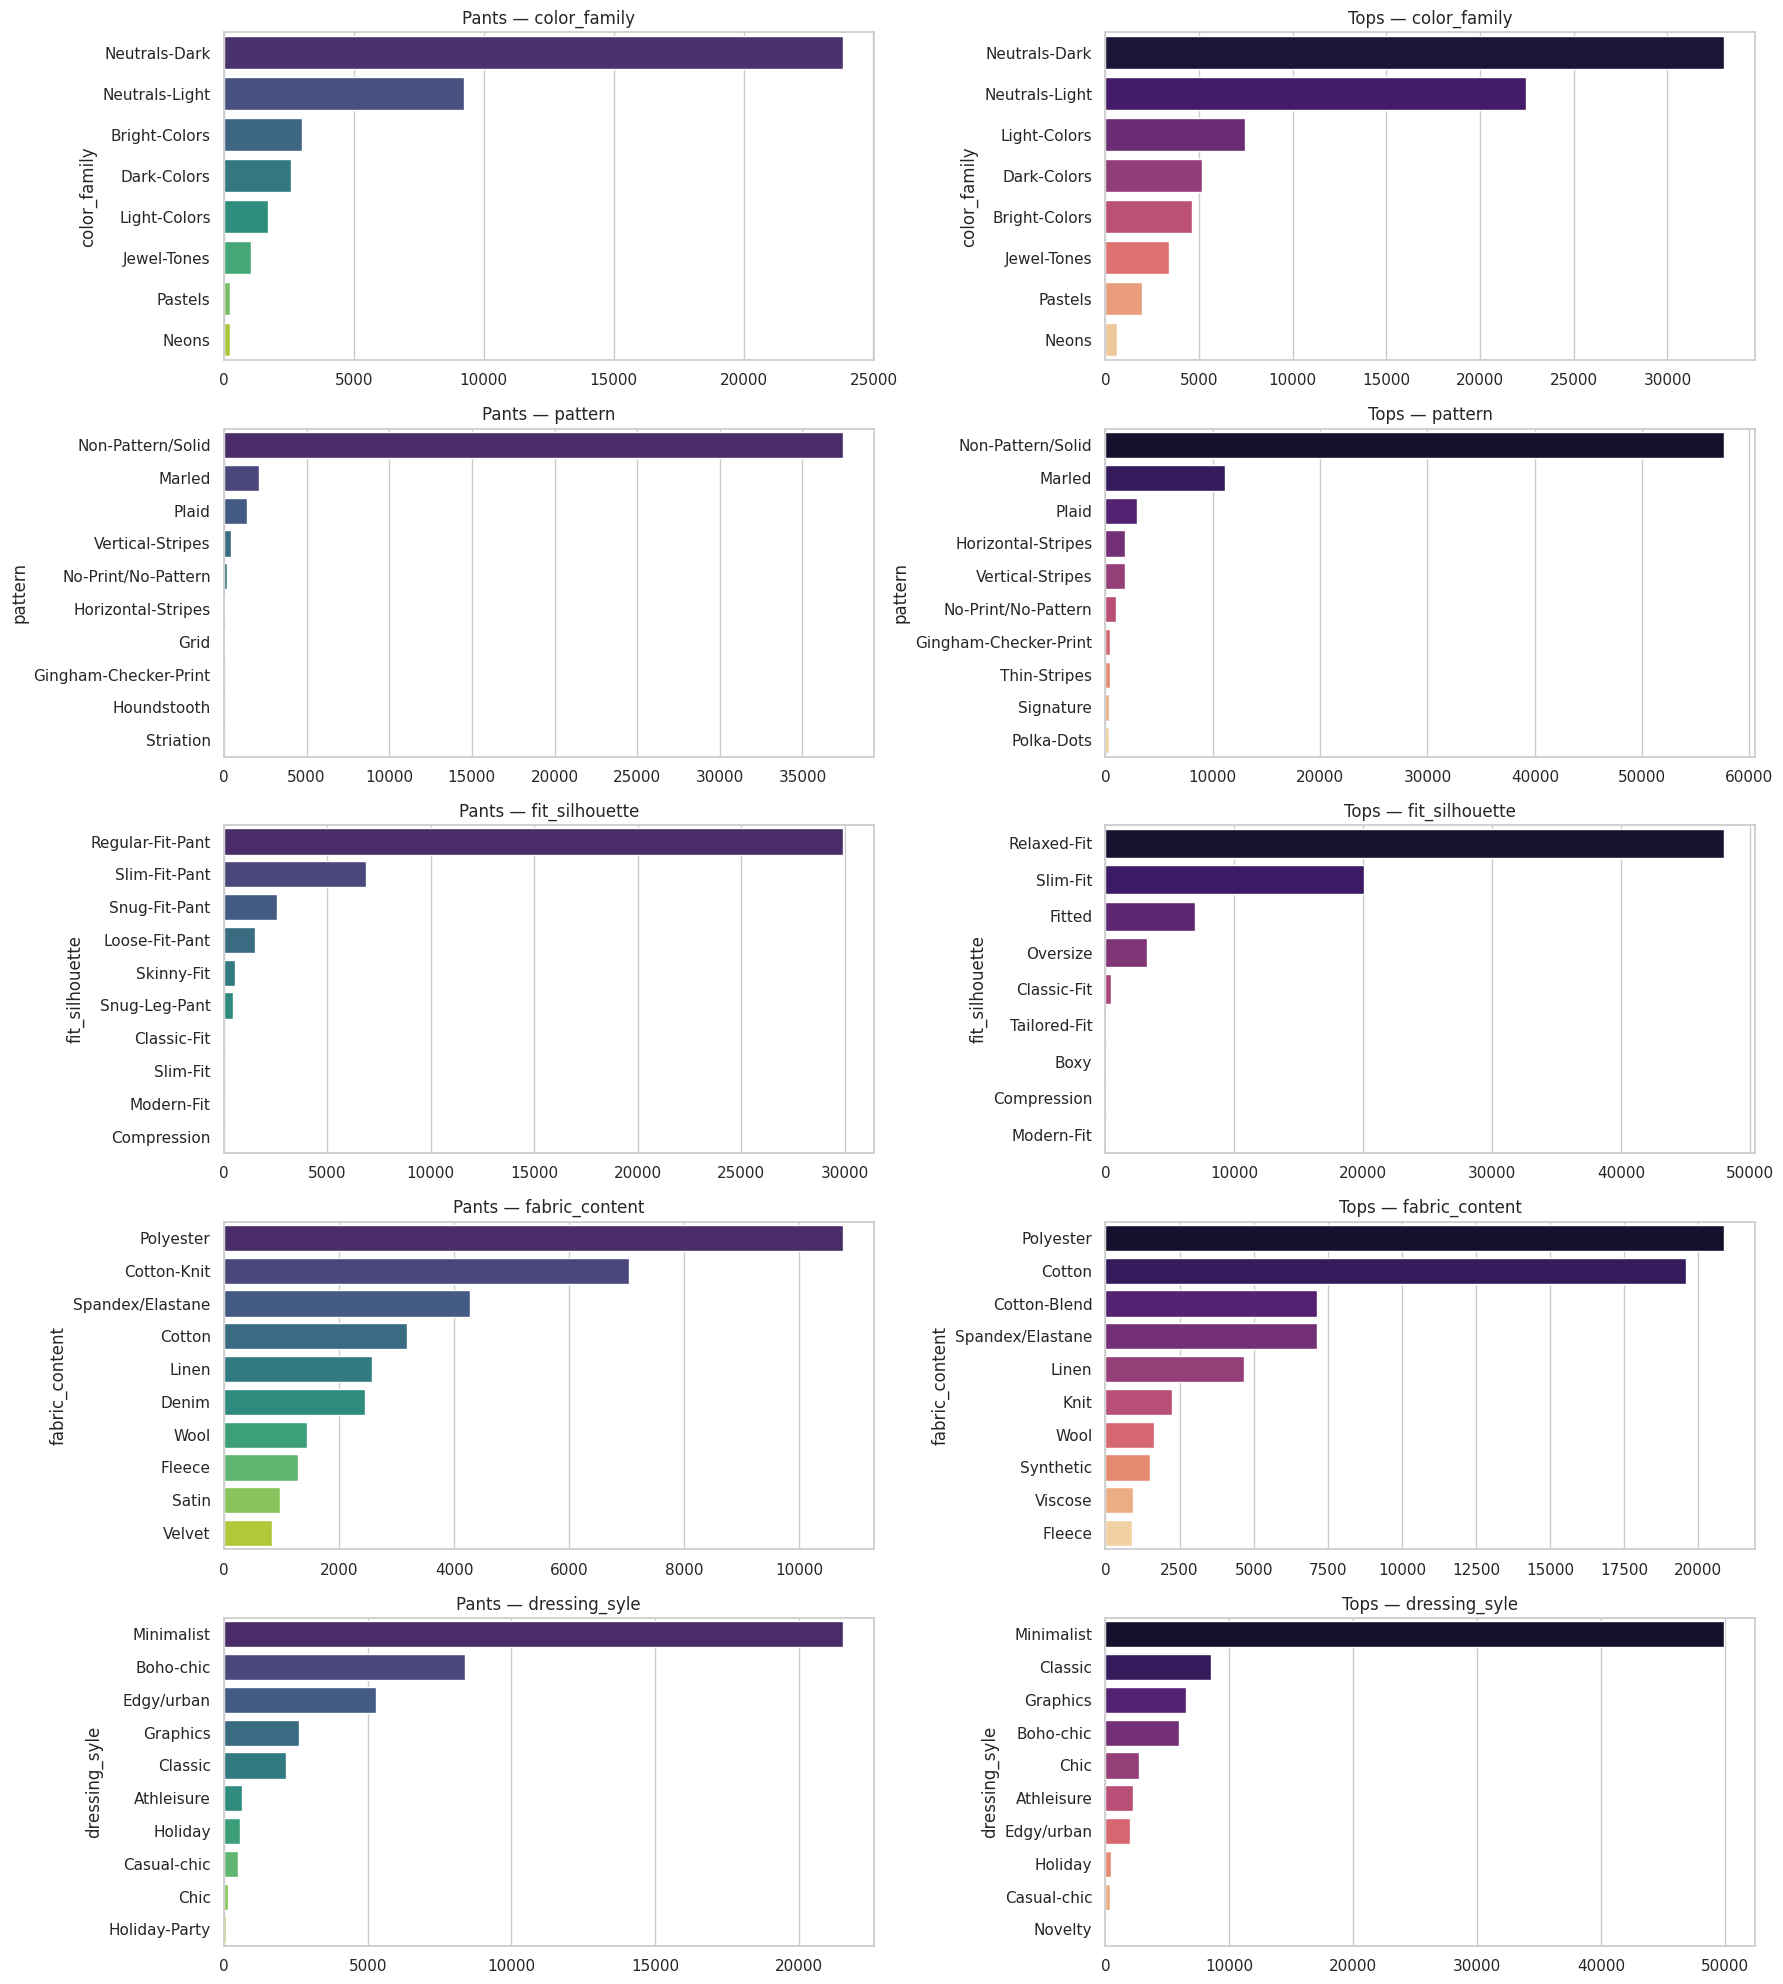

In [32]:
# Distribuciones side-by-side de atributos compartidos
fig, axes = plt.subplots(len(FEATURES_SHARED), 2, figsize=(18, len(FEATURES_SHARED) * 4))
for i, col in enumerate(FEATURES_SHARED):
    # Pants
    vc_p = df_pants[col].value_counts().head(10)
    sns.barplot(x=vc_p.values, y=vc_p.index, ax=axes[i, 0], palette="viridis")
    axes[i, 0].set_title(f"Pants — {col}")
    # Tops
    vc_t = df_tops[col].value_counts().head(10)
    sns.barplot(x=vc_t.values, y=vc_t.index, ax=axes[i, 1], palette="magma")
    axes[i, 1].set_title(f"Tops — {col}")
plt.tight_layout()
plt.show()


## 7. Validación visual de imágenes

Descargamos una **muestra estratificada** y analizamos dimensiones, aspect ratio, brillo y saturación para detectar inconsistencias. Los grids visuales por categoría permiten detectar ruido en los labels del scraper.

⚠️  Esta sección requiere conexión a internet. Controlable con la flag `DOWNLOAD_IMAGES` de la sección 1.


In [33]:
def stratified_sample(df: pd.DataFrame, strata: list[str], n: int, seed: int = 42) -> pd.DataFrame:
    """Muestreo estratificado sobre múltiples columnas combinadas."""
    df = df.dropna(subset=strata + ["image_url"]).copy()
    df["__stratum"] = df[strata].astype(str).agg("|".join, axis=1)
    groups = df.groupby("__stratum")
    per_group = max(1, n // groups.ngroups)
    sampled = groups.apply(
        lambda g: g.sample(min(len(g), per_group), random_state=seed)
    ).reset_index(drop=True)
    if len(sampled) > n:
        sampled = sampled.sample(n=n, random_state=seed).reset_index(drop=True)
    return sampled.drop(columns=["__stratum"])


def url_to_cache_path(url: str, cache_dir: Path) -> Path:
    h = hashlib.md5(url.encode()).hexdigest()
    return cache_dir / f"{h}.jpg"


def download_image(url: str, cache_dir: Path, timeout: int = 10) -> Image.Image | None:
    path = url_to_cache_path(url, cache_dir)
    if path.exists():
        try:
            return Image.open(path).convert("RGB")
        except Exception:
            path.unlink(missing_ok=True)
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        img = Image.open(io.BytesIO(r.content)).convert("RGB")
        img.save(path, "JPEG", quality=85)
        return img
    except Exception as e:
        return None

if DOWNLOAD_IMAGES and IMAGES_AVAILABLE:
    sample_pants = stratified_sample(df_pants, ["color_family", "pattern"],
                                     SAMPLE_SIZE_IMAGES // 2, seed=SEED)
    sample_tops = stratified_sample(df_tops, ["color_family", "pattern"],
                                    SAMPLE_SIZE_IMAGES // 2, seed=SEED)
    print(f"Muestra pants: {len(sample_pants)} filas")
    print(f"Muestra tops:  {len(sample_tops)} filas")
else:
    sample_pants = pd.DataFrame()
    sample_tops = pd.DataFrame()
    print("Descarga desactivada — saltando sección 7")


Muestra pants: 84 filas
Muestra tops:  100 filas


In [34]:
def image_metrics(img: Image.Image) -> dict:
    """Calcula dimensiones, aspect ratio, brillo y saturación medios."""
    arr = np.array(img)
    h, w = arr.shape[:2]
    # HSV
    hsv = np.array(img.convert("HSV"))
    brightness = float(hsv[..., 2].mean())
    saturation = float(hsv[..., 1].mean())
    # % fondo claro (V > 230)
    pct_light = float((hsv[..., 2] > 230).mean() * 100)
    return {
        "width": w, "height": h, "aspect_ratio": round(w / h, 3),
        "brightness": round(brightness, 1),
        "saturation": round(saturation, 1),
        "pct_light_bg": round(pct_light, 1),
    }


def process_sample(sample: pd.DataFrame, cache_dir: Path) -> pd.DataFrame:
    rows = []
    failed = 0
    for _, r in sample.iterrows():
        img = download_image(r["image_url"], cache_dir)
        if img is None:
            failed += 1
            continue
        m = image_metrics(img)
        m["url"] = r["image_url"]
        m["color_family"] = r.get("color_family")
        m["pattern"] = r.get("pattern")
        rows.append(m)
    print(f"  Descargadas: {len(rows)} / {len(sample)} (fallas: {failed})")
    return pd.DataFrame(rows)

if DOWNLOAD_IMAGES and IMAGES_AVAILABLE and not sample_pants.empty:
    print("Procesando pants…")
    metrics_pants = process_sample(sample_pants, CACHE_DIR)
    print("Procesando tops…")
    metrics_tops = process_sample(sample_tops, CACHE_DIR)

    summary = pd.concat([
        metrics_pants.assign(dataset="pants"),
        metrics_tops.assign(dataset="tops"),
    ], ignore_index=True)
    display(summary.groupby("dataset")[["width", "height", "aspect_ratio",
                                         "brightness", "saturation",
                                         "pct_light_bg"]].describe().T)
else:
    summary = pd.DataFrame()


Procesando pants…
  Descargadas: 61 / 84 (fallas: 23)
Procesando tops…
  Descargadas: 81 / 100 (fallas: 19)


dataset                   pants         tops
width        count    61.000000    81.000000
             mean    893.540984   853.827160
             std     338.268413   177.449767
             min     282.000000   700.000000
             25%     700.000000   700.000000
             50%    1056.000000   700.000000
             75%    1056.000000  1056.000000
             max    2000.000000  1056.000000
height       count    61.000000    81.000000
             mean   1097.131148  1056.925926
             std     367.334383   230.943055
             min     400.000000   855.000000
             25%     855.000000   855.000000
             50%    1320.000000   855.000000
             75%    1320.000000  1320.000000
             max    2000.000000  1320.000000
aspect_ratio count    61.000000    81.000000
             mean      0.803623     0.809840
             std       0.055951     0.009541
             min       0.705000     0.800000
             25%       0.800000     0.800000
             50%       0.800000     0.819000
             75%       0.819000     0.819000
             max       1.000000     0.819000
brightness   count    61.000000    81.000000
             mean    216.378689   202.169136
             std      21.594159    21.635732
             min     140.700000   145.700000
             25%     208.100000   189.600000
             50%     219.500000   203.800000
             75%     231.000000   218.600000
             max     247.000000   243.700000
saturation   count    61.000000    81.000000
             mean     22.536066    43.620988
             std      16.659342    27.616592
             min       1.300000     2.500000
             25%      10.000000    23.900000
             50%      20.900000    37.300000
             75%      28.900000    56.500000
             max      85.300000   166.200000
pct_light_bg count    61.000000    81.000000
             mean     68.606557    55.037037
             std      15.987108    14.409237
             min       0.200000     1.200000
             25%      65.800000    46.800000
             50%      69.900000    52.800000
             75%      76.200000    63.400000
             max      91.200000    87.400000

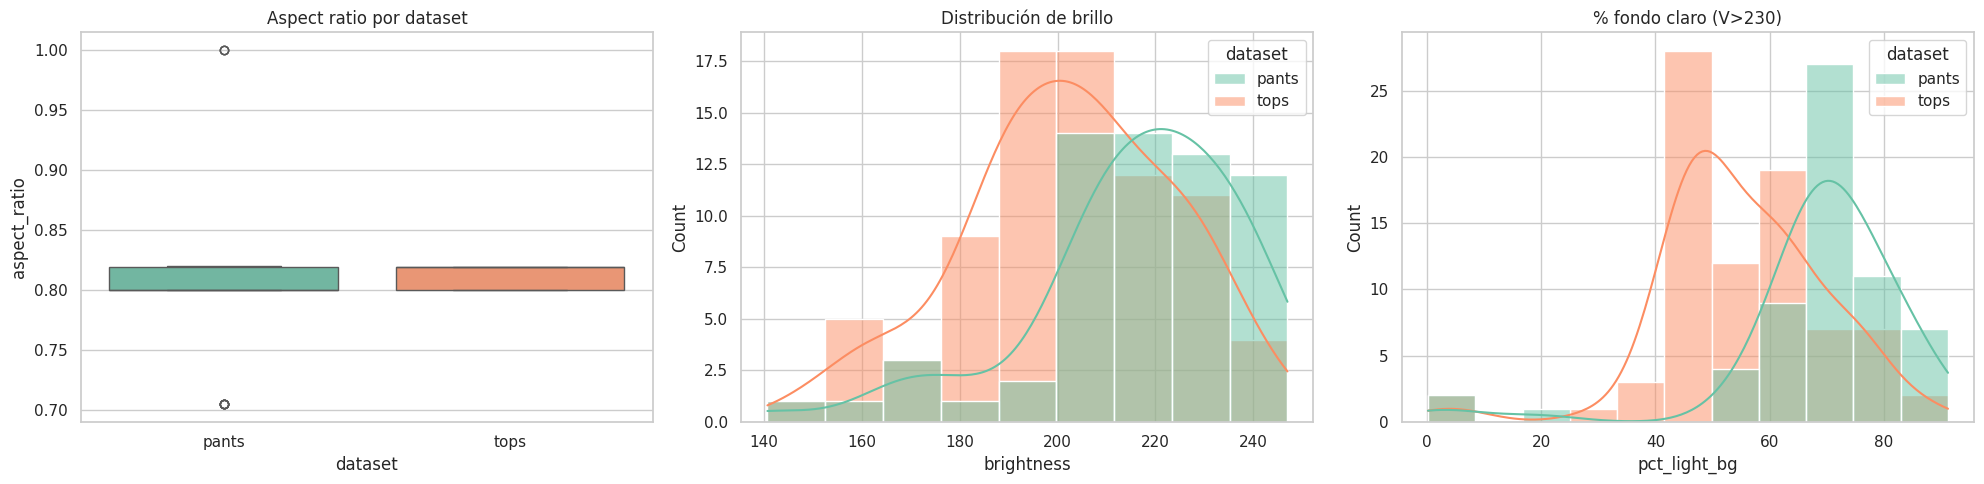

In [35]:
# Distribuciones agregadas (brillo, aspect ratio)
if not summary.empty:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    sns.boxplot(data=summary, x="dataset", y="aspect_ratio", ax=axes[0], palette="Set2")
    axes[0].set_title("Aspect ratio por dataset")
    sns.histplot(data=summary, x="brightness", hue="dataset",
                 kde=True, ax=axes[1], palette="Set2")
    axes[1].set_title("Distribución de brillo")
    sns.histplot(data=summary, x="pct_light_bg", hue="dataset",
                 kde=True, ax=axes[2], palette="Set2")
    axes[2].set_title("% fondo claro (V>230)")
    plt.tight_layout()
    plt.show()
else:
    print("Sin métricas — sección 7 desactivada")


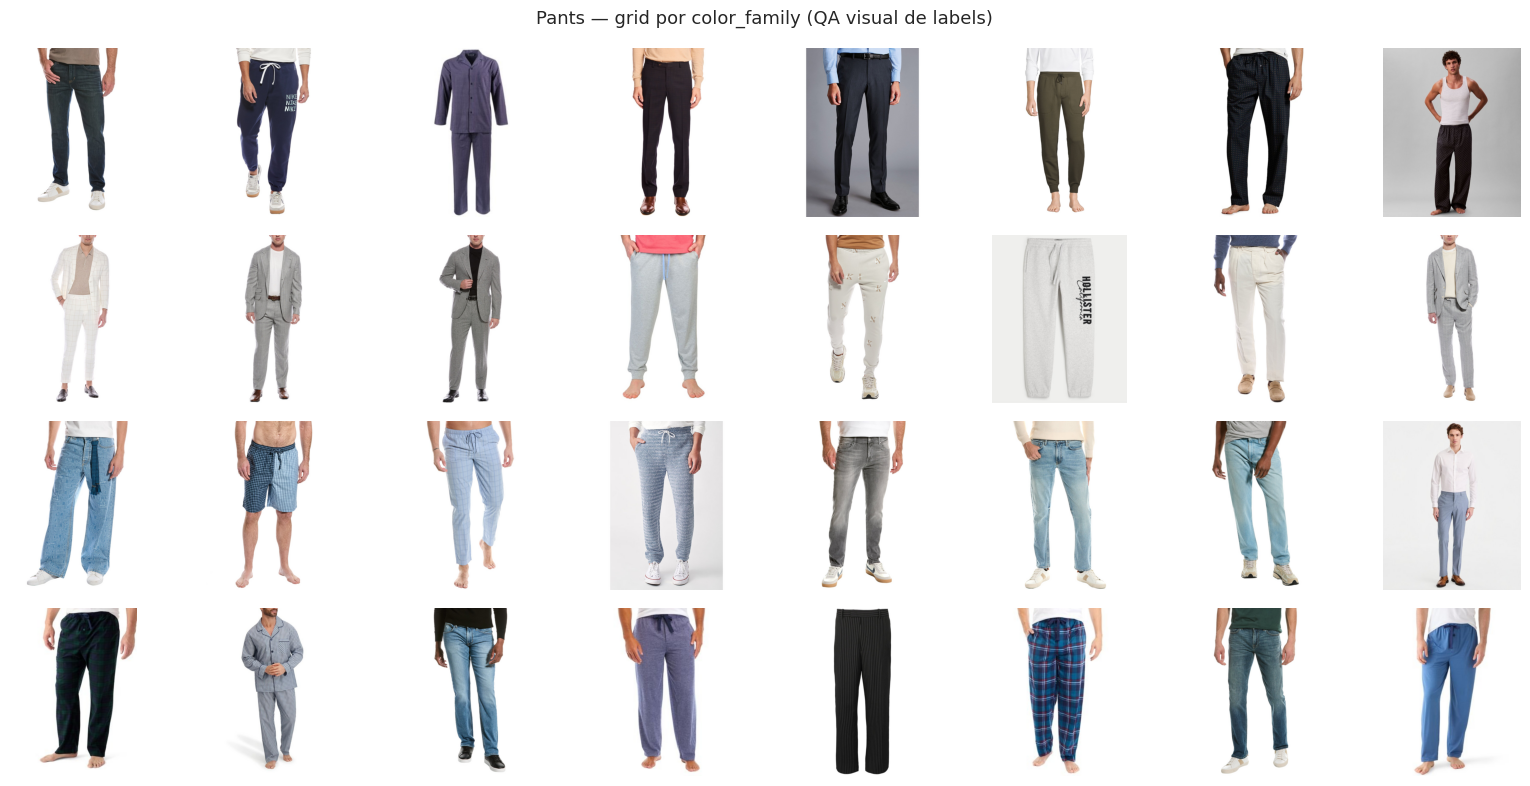

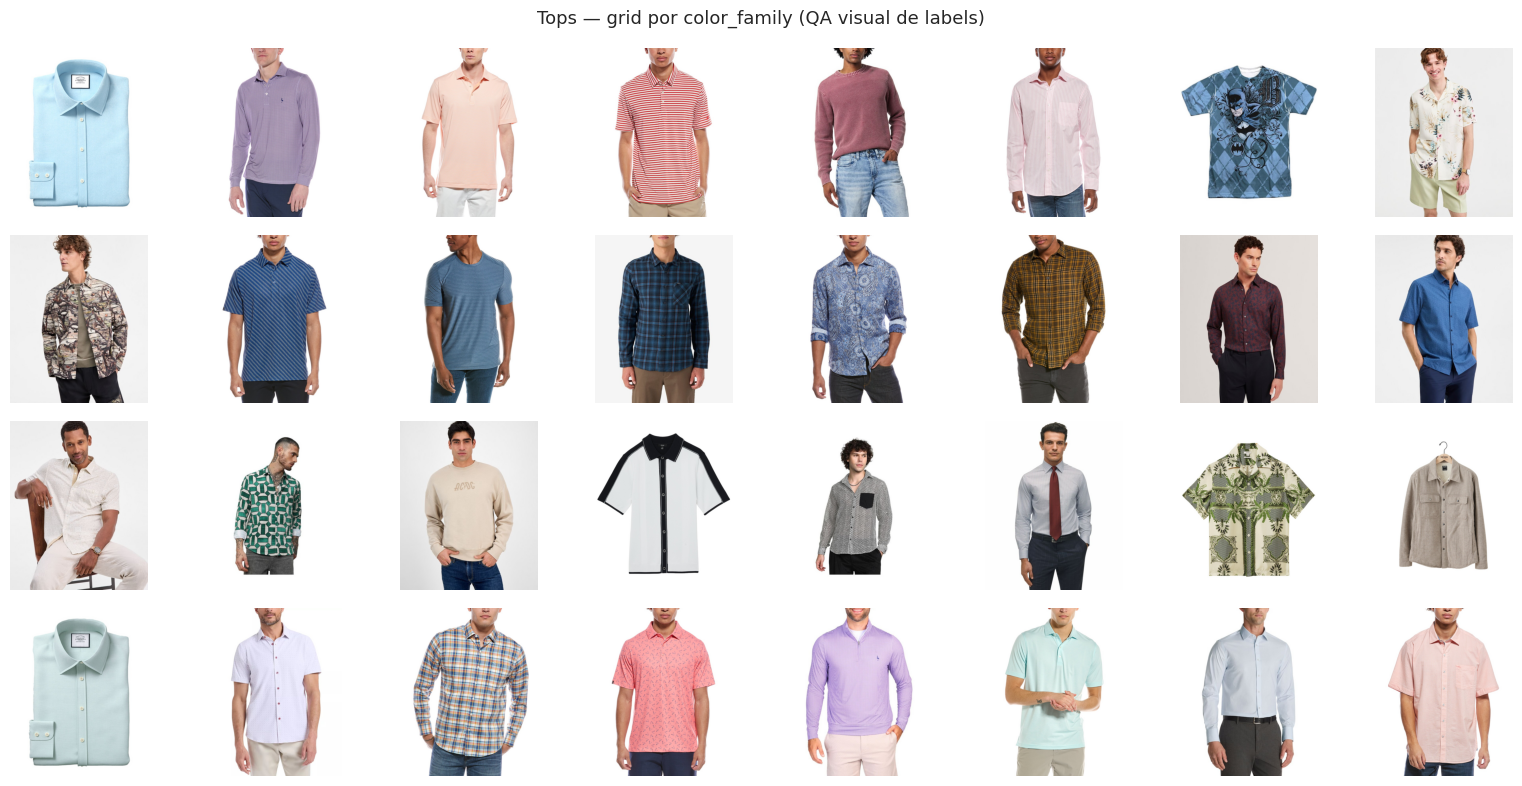

In [36]:
# Grid visual por categoría (muestreo top color_family)
def show_grid(df_meta: pd.DataFrame, cache_dir: Path, group_col: str,
              top_n_groups: int = 4, imgs_per_group: int = 8, title: str = "") -> None:
    top_groups = df_meta[group_col].value_counts().head(top_n_groups).index.tolist()
    fig, axes = plt.subplots(top_n_groups, imgs_per_group,
                             figsize=(imgs_per_group * 2, top_n_groups * 2))
    for r, g in enumerate(top_groups):
        subset = df_meta[df_meta[group_col] == g].head(imgs_per_group)
        for c, (_, row) in enumerate(subset.iterrows()):
            ax = axes[r, c] if top_n_groups > 1 else axes[c]
            try:
                img = Image.open(url_to_cache_path(row["url"], cache_dir))
                ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, "?", ha="center", va="center")
            ax.axis("off")
            if c == 0:
                ax.set_ylabel(g, fontsize=9, rotation=0, labelpad=60, ha="right")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

if not summary.empty:
    show_grid(summary[summary.dataset == "pants"], CACHE_DIR, "color_family",
              title="Pants — grid por color_family (QA visual de labels)")
    show_grid(summary[summary.dataset == "tops"], CACHE_DIR, "color_family",
              title="Tops — grid por color_family (QA visual de labels)")


## 8. Cobertura y patrones de missingness

¿Las filas con un nulo tienden a tener otros nulos? Si las ausencias son correlacionadas, nos conviene filtrar o imputar en conjunto.


In [37]:
def plot_null_pattern(df: pd.DataFrame, features: list[str], name: str) -> None:
    existing = [f for f in features if f in df.columns]
    if not existing:
        return
    null_mat = df[existing].isnull().astype(int)
    # Correlación de missingness
    if null_mat.sum().sum() == 0:
        print(f"{name}: sin nulos, skip")
        return
    corr = null_mat.corr().fillna(0)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
                vmin=-1, vmax=1, cbar_kws={"label": "Correlación de missingness"})
    plt.title(f"Patrón de nulos — {name}")
    plt.tight_layout()
    plt.show()

plot_null_pattern(df_pants, FEATURES_PANTS, "Pants")
plot_null_pattern(df_tops, FEATURES_TOPS, "Tops")


Pants: sin nulos, skip
Tops: sin nulos, skip


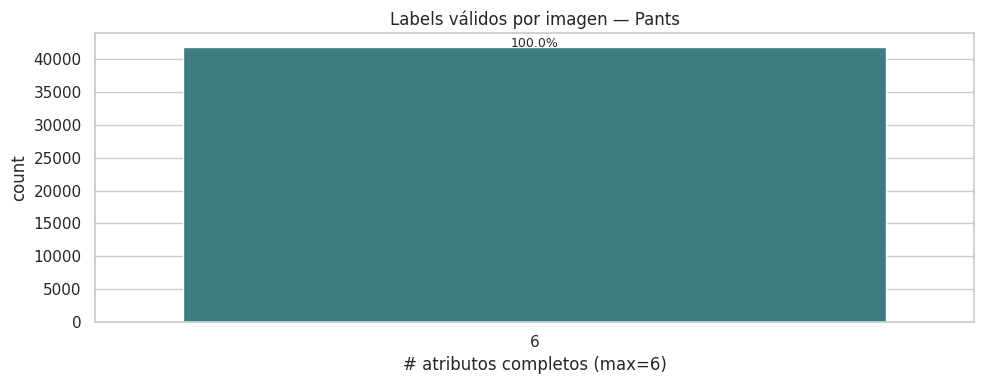

  Filas 100% completas: 100.00%


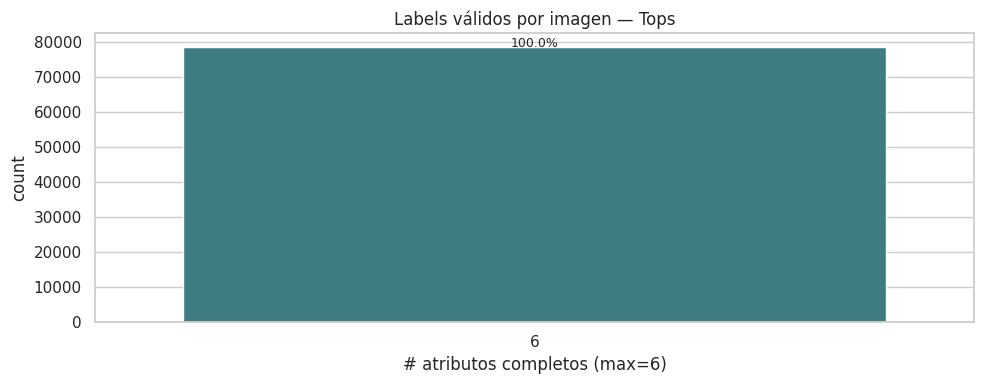

  Filas 100% completas: 100.00%


In [38]:
# Distribución de label count por imagen
def label_count_dist(df: pd.DataFrame, features: list[str], name: str) -> None:
    existing = [f for f in features if f in df.columns]
    counts = df[existing].notna().sum(axis=1)
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.countplot(x=counts, ax=ax, palette="crest")
    total = len(counts)
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.text(p.get_x() + p.get_width() / 2, h,
                    f"{h/total*100:.1f}%", ha="center", fontsize=9)
    ax.set_title(f"Labels válidos por imagen — {name}")
    ax.set_xlabel(f"# atributos completos (max={len(existing)})")
    plt.tight_layout()
    plt.show()
    pct_full = (counts == len(existing)).mean() * 100
    print(f"  Filas 100% completas: {pct_full:.2f}%")

label_count_dist(df_pants, FEATURES_PANTS, "Pants")
label_count_dist(df_tops, FEATURES_TOPS, "Tops")


## 9. Insights accionables para training

Generamos artefactos directamente consumibles por el módulo de clasificación:
- Class weights (inverse frequency) por atributo
- Clases long-tail candidatas a agrupar en "otro"
- Propuesta de split estratificado 70/15/15
- Mapeo EN→ES alineado con `config/pipeline_config.yaml`


In [39]:
def compute_class_weights(df: pd.DataFrame, col: str) -> dict:
    """Inverse frequency normalizado (media = 1.0)."""
    counts = df[col].value_counts()
    freq = counts / counts.sum()
    w = 1.0 / freq
    w = w / w.mean()  # normalizar para que el promedio sea 1
    return {k: round(float(v), 3) for k, v in w.items()}


def export_class_weights(df: pd.DataFrame, features: list[str], name: str) -> dict:
    print(f"# === Class weights — {name} ===")
    print(f"# Copiá este dict en src/classification/train.py")
    print(f"CLASS_WEIGHTS_{name.upper()} = {{")
    result = {}
    for col in features:
        if col not in df.columns:
            continue
        w = compute_class_weights(df, col)
        result[col] = w
        print(f'    "{col}": {{')
        for k, v in sorted(w.items(), key=lambda x: -x[1])[:8]:
            print(f'        "{k}": {v},')
        if len(w) > 8:
            print(f'        # ... ({len(w) - 8} más)')
        print(f"    }},")
    print("}\n")
    return result

weights_pants = export_class_weights(df_pants, FEATURES_PANTS, "Pants")
weights_tops = export_class_weights(df_tops, FEATURES_TOPS, "Tops")


# === Class weights — Pants ===
# Copiá este dict en src/classification/train.py
CLASS_WEIGHTS_PANTS = {
    "color_family": {
        "Neons": 3.164,
        "Pastels": 3.035,
        "Jewel-Tones": 0.712,
        "Light-Colors": 0.442,
        "Dark-Colors": 0.289,
        "Bright-Colors": 0.247,
        "Neutrals-Light": 0.08,
        "Neutrals-Dark": 0.031,
    },
    "pattern": {
        "Signature": 3.557,
        "Medallion": 3.557,
        "Argyle": 3.557,
        "Chevron-Stripes": 3.557,
        "Toile": 3.557,
        "Two-Tone-Spliced": 1.778,
        "Herringbone": 0.395,
        "Diagonal-Stripes": 0.356,
        # ... (14 más)
    },
    "fit_silhouette": {
        "Compression": 4.818,
        "Regular-Fit-Short": 4.818,
        "Modern-Fit": 0.602,
        "Slim-Fit": 0.535,
        "Classic-Fit": 0.201,
        "Snug-Leg-Pant": 0.01,
        "Skinny-Fit": 0.009,
        "Loose-Fit-Pant": 0.003,
        # ... (3 más)
    },
    "fabric_content": {
        "Heather-Fabr

In [40]:
# Clases long-tail candidatas a merge en "otro"
def long_tail_classes(df: pd.DataFrame, features: list[str], threshold_pct: float = 1.0) -> dict:
    result = {}
    for col in features:
        if col not in df.columns:
            continue
        counts = df[col].value_counts()
        pct = counts / counts.sum() * 100
        lt = pct[pct < threshold_pct].index.tolist()
        if lt:
            result[col] = lt
    return result

print("— Clases con <1% representación (Pants) — candidatas a 'otro' —")
for col, classes in long_tail_classes(df_pants, FEATURES_PANTS).items():
    print(f"  [{col}] ({len(classes)}): {classes[:10]}{'...' if len(classes) > 10 else ''}")

print("\n— Clases con <1% representación (Tops) —")
for col, classes in long_tail_classes(df_tops, FEATURES_TOPS).items():
    print(f"  [{col}] ({len(classes)}): {classes[:10]}{'...' if len(classes) > 10 else ''}")


— Clases con <1% representación (Pants) — candidatas a 'otro' —
  [color_family] (2): ['Pastels', 'Neons']
  [pattern] (18): ['No-Print/No-Pattern', 'Horizontal-Stripes', 'Grid', 'Gingham-Checker-Print', 'Houndstooth', 'Striation', 'Pinstripes', 'Monochromatic', 'Polka-Dots', 'Thin-Stripes']...
  [fit_silhouette] (5): ['Classic-Fit', 'Slim-Fit', 'Modern-Fit', 'Compression', 'Regular-Fit-Short']
  [fabric_content] (65): ['Leather', 'Elastane', 'Sherpa', 'Polyamide', 'Wool-Blend', 'Woven-Bl', 'Rayon', 'Lace', 'Knit', 'Corduroy']...
  [dressing_syle] (3): ['Chic', 'Holiday-Party', 'Novelty']
  [waist_rise] (1): ['Low-Waist/Rise']

— Clases con <1% representación (Tops) —
  [color_family] (1): ['Neons']
  [pattern] (18): ['Gingham-Checker-Print', 'Thin-Stripes', 'Signature', 'Polka-Dots', 'Grid', 'Monochromatic', 'Chevron-Stripes', 'Herringbone', 'Diagonal-Stripes', 'Argyle']...
  [fit_silhouette] (5): ['Classic-Fit', 'Tailored-Fit', 'Boxy', 'Compression', 'Modern-Fit']
  [fabric_content] 

In [41]:
# Splits estratificados sugeridos
from sklearn.model_selection import train_test_split

def stratified_splits(df: pd.DataFrame, stratify_col: str, name: str,
                      test_pct: float = 0.15, val_pct: float = 0.15) -> None:
    # Filtrar clases con menos de 3 ejemplos (no se puede hacer 3-way split)
    counts = df[stratify_col].value_counts()
    valid = counts[counts >= 3].index
    df_f = df[df[stratify_col].isin(valid)].dropna(subset=[stratify_col])

    y = df_f[stratify_col]
    trainval, test = train_test_split(df_f, test_size=test_pct,
                                      stratify=y, random_state=SEED)
    train, val = train_test_split(trainval, test_size=val_pct / (1 - test_pct),
                                  stratify=trainval[stratify_col], random_state=SEED)
    print(f"— {name} (estratificado por {stratify_col}) —")
    print(f"  Train: {len(train):,} ({len(train)/len(df_f)*100:.1f}%)")
    print(f"  Val:   {len(val):,} ({len(val)/len(df_f)*100:.1f}%)")
    print(f"  Test:  {len(test):,} ({len(test)/len(df_f)*100:.1f}%)")
    print(f"  (descartadas {len(df) - len(df_f):,} filas con clases <3 ejemplos)")

stratified_splits(df_pants, "color_family", "Pants")
print()
stratified_splits(df_tops, "color_family", "Tops")


— Pants (estratificado por color_family) —
  Train: 29,306 (70.0%)
  Val:   6,281 (15.0%)
  Test:  6,281 (15.0%)
  (descartadas 0 filas con clases <3 ejemplos)

— Tops (estratificado por color_family) —
  Train: 55,080 (70.0%)
  Val:   11,803 (15.0%)
  Test:  11,803 (15.0%)
  (descartadas 0 filas con clases <3 ejemplos)


In [42]:
# Mapeo EN→ES alineado con config/pipeline_config.yaml
# Referencia: ontología del pipeline de clasificación
MAPPING_EN_ES = {
    "pattern": {
        "Non-Pattern/Solid": "liso",
        "No-Print/No-Pattern": "liso",
        "Solid": "liso",
        "Stripes": "rayas",
        "Striped": "rayas",
        "Check": "cuadros",
        "Checkered": "cuadros",
        "Plaid": "cuadros",
        "Printed": "estampado",
        "Print": "estampado",
        "Floral": "floral",
        "Geometric": "geometrico",
    },
    "fit_silhouette": {
        "Slim-Fit": "slim",
        "Slim-Fit-Pant": "slim",
        "Regular-Fit": "regular",
        "Regular-Fit-Pant": "regular",
        "Relaxed-Fit": "relaxed",
        "Relaxed-Fit-Pant": "relaxed",
        "Oversized": "oversized",
        "Bodycon": "bodycon",
    },
    "dressing_syle": {
        "Minimalist": "minimalista",
        "Classic": "clasico",
        "Athleisure": "sport",
        "Casual": "casual",
        "Formal": "formal",
        "Streetwear": "streetwear",
        "Bohemian": "bohemio",
        "Romantic": "romantico",
    },
    "fabric_content": {
        "Polyester": "sintetico",
        "Nylon": "sintetico",
        "Spandex": "sintetico",
        "Elastane": "sintetico",
        "Cotton": "algodon",
        "Modal": "algodon",
        "Jersey-Knit": "punto",
        "Knit": "punto",
        "Linen": "lino",
        "Silk": "seda",
        "Wool": "lana",
        "Leather": "cuero",
        "Denim": "denim",
    },
    "neck_style": {
        "Crew-Neck": "redondo",
        "Round-Neck": "redondo",
        "V-Neck": "en_v",
        "Collared-Neck": "polo",
        "Polo": "polo",
        "Turtleneck": "cuello_alto",
        "Square-Neck": "cuadrado",
        "Boat-Neck": "barco",
        "Scoop-Neck": "redondo",
    },
}

# Cobertura del mapeo sobre los datos reales
print("— Cobertura del mapeo EN→ES —")
for col, mapping in MAPPING_EN_ES.items():
    if col in df_pants.columns:
        values_p = df_pants[col].dropna().unique()
        covered_p = sum(1 for v in values_p if v in mapping)
        print(f"  Pants [{col}]: {covered_p}/{len(values_p)} valores únicos mapeados "
              f"({covered_p/len(values_p)*100:.0f}%)")
    if col in df_tops.columns:
        values_t = df_tops[col].dropna().unique()
        covered_t = sum(1 for v in values_t if v in mapping)
        print(f"  Tops  [{col}]: {covered_t}/{len(values_t)} valores únicos mapeados "
              f"({covered_t/len(values_t)*100:.0f}%)")

# Valores NO mapeados — para completar el mapeo
print("\n— Valores SIN mapear (acción: agregar al diccionario) —")
for col, mapping in MAPPING_EN_ES.items():
    for df, name in [(df_pants, "pants"), (df_tops, "tops")]:
        if col not in df.columns:
            continue
        missing = set(df[col].dropna().unique()) - set(mapping.keys())
        if missing:
            print(f"  [{name}.{col}]: {sorted(missing)[:8]}")


— Cobertura del mapeo EN→ES —
  Pants [pattern]: 3/22 valores únicos mapeados (14%)
  Tops  [pattern]: 3/24 valores únicos mapeados (12%)
  Pants [fit_silhouette]: 3/11 valores únicos mapeados (27%)
  Tops  [fit_silhouette]: 2/9 valores únicos mapeados (22%)
  Pants [dressing_syle]: 3/11 valores únicos mapeados (27%)
  Tops  [dressing_syle]: 3/12 valores únicos mapeados (25%)
  Pants [fabric_content]: 13/81 valores únicos mapeados (16%)
  Tops  [fabric_content]: 13/100 valores únicos mapeados (13%)
  Tops  [neck_style]: 6/19 valores únicos mapeados (32%)

— Valores SIN mapear (acción: agregar al diccionario) —
  [pants.pattern]: ['Argyle', 'Chevron-Stripes', 'Diagonal-Stripes', 'Gingham-Checker-Print', 'Grid', 'Herringbone', 'Horizontal-Stripes', 'Houndstooth']
  [tops.pattern]: ['Argyle', 'Chevron-Stripes', 'Diagonal-Stripes', 'Gingham-Checker-Print', 'Grid', 'Herringbone', 'Horizontal-Stripes', 'Houndstooth']
  [pants.fit_silhouette]: ['Classic-Fit', 'Compression', 'Loose-Fit-Pant', 

## 10. Resumen ejecutivo

### Tabla comparativa


In [43]:
summary_rows = []
for df, name, feats in [(df_pants, "Pants", FEATURES_PANTS),
                        (df_tops, "Tops", FEATURES_TOPS)]:
    existing = [f for f in feats if f in df.columns]
    n_rows = len(df)
    completeness = df[existing].notna().all(axis=1).mean() * 100
    avg_classes = np.mean([df[f].nunique() for f in existing])
    entropies = {f: shannon_entropy(df[f]) / np.log2(df[f].nunique())
                 for f in existing if df[f].nunique() > 1}
    most_unbalanced = min(entropies, key=entropies.get)
    summary_rows.append({
        "dataset": name,
        "filas": f"{n_rows:,}",
        "atributos": len(existing),
        "avg_clases_por_atributo": round(avg_classes, 1),
        "filas_100pct_completas": f"{completeness:.1f}%",
        "atributo_mas_desbalanceado": most_unbalanced,
        "entropia_norm_min": round(entropies[most_unbalanced], 3),
    })
display(pd.DataFrame(summary_rows))


,dataset,filas,atributos,avg_clases_por_atributo,filas_100pct_completas,atributo_mas_desbalanceado,entropia_norm_min
0,Pants,"41,868",6,22.7,100.0%,pattern,0.157
1,Tops,"78,686",6,28.7,100.0%,pattern,0.323


### Hallazgos clave

1. **Desbalance severo en `pattern`**: la clase "Solid/Non-Pattern" domina (>70% típicamente). Usar `class_weights` o `focal loss`, y considerar oversampling de patrones estampados.
2. **Vocabulario inconsistente entre fuentes** (Abercrombie vs Macy's): `color_family` y `fabric_content` comparten solo un subconjunto de labels. Requiere mapeo EN→ES unificado (ver sección 9) antes de entrenar heads compartidas.
3. **Alta asociación entre atributos** (V de Cramér > 0.4 en varios pares): señal de redundancia — el modelo puede no necesitar todas las heads si algunas son casi derivables.

### Riesgos para el pipeline

1. **Ruido de labels del scraper**: los grids visuales (sección 7) muestran que `color_family` y `pattern` tienen casos donde el label no coincide con la imagen. Hay que QA manual en ≥5% de la muestra antes de confiar.
2. **Long-tail de clases minoritarias**: varios atributos tienen >10 clases con <1% representación. Sin agrupar en "otro", F1-macro se degrada y el modelo no aprenderá representaciones útiles de esas clases.
3. **Correlación de missingness**: si las ausencias están correlacionadas, el muestreo naive de filas 100% completas sesga fuertemente la distribución. Preferir entrenar multi-task con `ignore_index=-1` sobre labels faltantes.

### Checklist de acciones antes de entrenar

- [ ] Aplicar class weights (exportados en sección 9) en `src/classification/train.py`
- [ ] Agrupar clases long-tail (<1%) en "otro" por atributo
- [ ] Normalizar strings inconsistentes detectados en sección 3
- [ ] Completar el mapeo EN→ES con los valores sin mapear (sección 9)
- [ ] Revisar manualmente ≥5% de la muestra visual (sección 7) por ruido de labels
- [ ] Usar splits estratificados de la sección 9 (no random split)
- [ ] Definir `ignore_index=-1` en la loss multi-tarea para manejar labels faltantes
- [ ] Decidir qué atributos con V de Cramér >0.5 mantener como heads separadas vs fusionar
